In [52]:
import torch
import matplotlib.pyplot as plt
import torchvision.transforms as T

import torch.nn.functional as F
import numpy as np
from PIL import Image

In [71]:

H, W = 64, 64
K = 249

# Delta PSF (impulse at center)
psf = torch.zeros(1, 1, K, K)
psf[0, 0, K//8, K//8] = 1.0

psf[0, 0, K//2 , K//2 ] = 1.0

psf[0, 0, K - 50, K //2] = 1.0

# Random image
y = torch.randn(1, 1, H, W) 

(np.float64(-0.5), np.float64(248.5), np.float64(248.5), np.float64(-0.5))

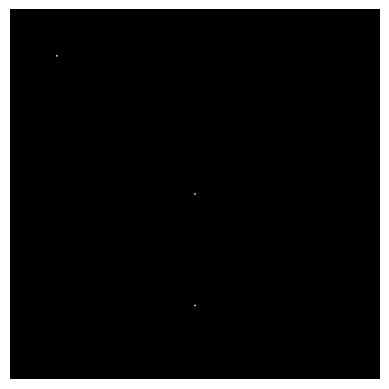

In [72]:
plt.imshow(psf.squeeze().detach().cpu().numpy(), cmap="gray")
plt.axis('off')

In [4]:
img_before = Image.open('/home/jmathew_waller/workspace/convolutions/convolution test image smaller.png').convert('L')
img_before = np.array(img_before)
img = img_before.copy()

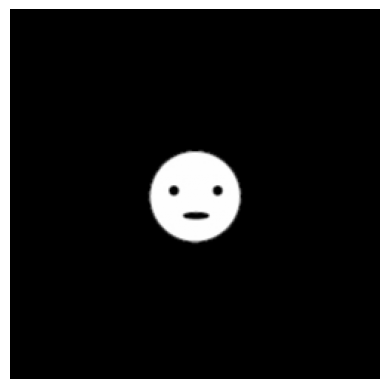

torch.Size([1, 1, 250, 250])


In [5]:
plt.imshow(img, cmap="gray")
plt.axis('off')
plt.show()

transform = T.ToTensor()
y_real = transform(img) 
y_real = y_real.unsqueeze(0) 
print(y_real.shape)

In [6]:
def wiener_deconv(y, psf, lam=1e-3):
    """
    y:   (B,1,H,W) real
    psf: (1,1,K,K) real
    lam: positive scalar float
    """
    B, C, H, W = y.shape
    K = psf.shape[-1]
    
    # Create padded PSF
    psf_pad = torch.zeros((1,1,H,W), device=y.device, dtype=y.dtype)
    
    # ISSUE: You want the PSF centered, not in the top-left corner
    # Place PSF at center before ifftshift
    pad_h = (H - K) // 2
    pad_w = (W - K) // 2
    psf_pad[..., pad_h:pad_h+K, pad_w:pad_w+K] = psf
    
    # Shift so DC component is at (0,0) for FFT
    psf_pad = torch.fft.ifftshift(psf_pad, dim=(-2, -1))
    
    # Frequency domain operations
    Y  = torch.fft.fft2(y)
    Hf = torch.fft.fft2(psf_pad)
    
    # Wiener filter
    Xhat = torch.conj(Hf) * Y / (torch.abs(Hf)**2 + lam)
    
    return torch.fft.ifft2(Xhat).real

In [65]:
def convolve(x, psf, padding=K//2):
    # conv2d does correlation; flipping makes it convolution
    psf_conv = torch.flip(psf, dims=(-2, -1))
    K = psf.shape[-1]
    return F.conv2d(x, psf_conv, padding=padding)

torch.Size([1, 1, 250, 250])


(np.float64(-0.5), np.float64(249.5), np.float64(249.5), np.float64(-0.5))

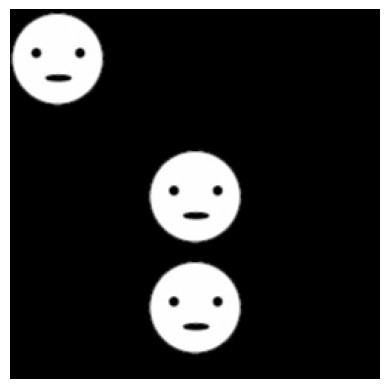

In [73]:
y_id = convolve(y_real, psf, padding=K//2)
print(y_id.shape)
plt.imshow(y_id.squeeze().detach().cpu().numpy(), cmap="gray")
plt.axis('off')

In [74]:
x_hat = wiener_deconv(y_id, psf, lam=1e-6)
print(y_id.shape)
print("identity MAE:", (x_hat - y_real).abs().mean().item())



torch.Size([1, 1, 250, 250])
identity MAE: 0.003369369311258197


(np.float64(-0.5), np.float64(249.5), np.float64(249.5), np.float64(-0.5))

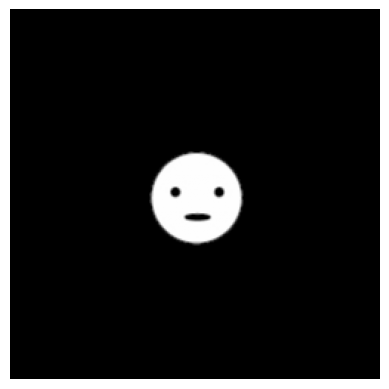

In [75]:
plt.imshow(x_hat.squeeze().detach().cpu().numpy(), cmap="gray")
plt.axis('off')